In [1]:
!pip install qiskit qiskit-aer qiskit-machine-learning torchvision --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 68.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 101.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 36.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 6.8 MB/s eta 0:00:00


In [3]:
!pip install -q torch torchvision matplotlib scikit-learn
!pip install -q qiskit qiskit-machine-learning
!pip install -q seaborn

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Torch Imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [5]:
from sklearn.metrics import (
    precision_recall_fscore_support, 
    confusion_matrix, 
    accuracy_score
)


In [6]:
try:
    import qiskit
    from qiskit import QuantumCircuit
    from qiskit.circuit import ParameterVector
    from qiskit.primitives import Sampler
    
    try:
        from qiskit.visualization import circuit_drawer
    except ImportError:
        circuit_drawer = None
    
    from qiskit_machine_learning.neural_networks import SamplerQNN
    from qiskit_machine_learning.connectors import TorchConnector
except ImportError:
    print("Quantum libraries not fully installed")
    QuantumCircuit = None
    circuit_drawer = None

In [7]:
from PIL import Image


In [8]:
class Config:
    category = "bottle"
    base_path = "/kaggle/input/mvtec-ad"
    img_size = 64
    latent_dim = 4
    num_qubits = 4
    depth = 2
    batch_size = 16
    epochs = 50
    learning_rate_g = 0.00015
    learning_rate_d = 0.000075

config = Config()

In [9]:
class MVTecADLoader(Dataset):
    def __init__(self, root_dir, transform=None):
        # Find image files
        self.image_files = [
            os.path.join(root_dir, f) 
            for f in os.listdir(root_dir) 
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        
        # Default Transform
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Resize((config.img_size, config.img_size)),
                transforms.Grayscale(num_output_channels=1),
                transforms.ToTensor(),
                transforms.Normalize([0.5], [0.5])
            ])
        else:
            self.transform = transform

    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img = Image.open(self.image_files[idx]).convert('L')
        return self.transform(img), 0


In [10]:
def create_quantum_circuit(
    latent_dim=4, 
    num_qubits=4, 
    depth=2
):
    # Create parameter vectors
    input_params = ParameterVector('input', latent_dim)
    weights = ParameterVector('weight', num_qubits*2*depth)
    
    # Initialize Quantum Circuit
    qc = QuantumCircuit(num_qubits)
    
    # Input encoding
    for i in range(latent_dim):
        qc.rx(input_params[i], i)
    
    # Parametrized layers
    weight_idx = 0
    for _ in range(depth):
        for qubit in range(num_qubits):
            qc.ry(weights[weight_idx], qubit)
            weight_idx += 1
    
    return qc

In [11]:
class QuantumGenerator(nn.Module):
    def __init__(
        self, 
        latent_dim=4, 
        num_qubits=4, 
        depth=2
    ):
        super().__init__()
        
        # Create Quantum Circuit
        self.qc = create_quantum_circuit(
            latent_dim, num_qubits, depth
        )
        params = self.qc.parameters
        
        # Quantum Neural Network
        self.qnn = SamplerQNN(
            circuit=self.qc,
            input_params=params[:latent_dim],
            weight_params=params[latent_dim:],
            sampler=Sampler(),
            output_shape=2**num_qubits,
            input_gradients=True
        )
        
        # Hybrid Layer
        self.hybrid_layer = TorchConnector(
            self.qnn,
            initial_weights=torch.randn(
                len(params)-latent_dim
            )*0.01
        )
        
        # Post-processing
        self.post_process = nn.Linear(16, config.img_size**2)

    def forward(self, z):
        z = z.view(-1, 4)
        return self.post_process(
            self.hybrid_layer(z)
        ).view(-1, 1, config.img_size, config.img_size)

In [12]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(config.img_size*config.img_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

In [13]:
def train_qgan(
    generator, 
    discriminator, 
    train_loader
):
    device = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu'
    )
    
    generator = generator.to(device)
    discriminator = discriminator.to(device)
    
    # Optimizers
    opt_g = torch.optim.RMSprop(
        generator.parameters(), 
        lr=config.learning_rate_g
    )
    opt_d = torch.optim.RMSprop(
        discriminator.parameters(), 
        lr=config.learning_rate_d
    )
    
    # Tracking losses
    gen_losses = []
    disc_losses = []
    
    # Training Loop
    for epoch in range(config.epochs):
        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            
            # Generate random latent vectors
            z = torch.randn(
                config.batch_size*4, 
                config.latent_dim
            ).to(device)
            
            # Train Discriminator
            with torch.no_grad():
                fake_imgs = generator(z)
            
            real_loss = -torch.mean(discriminator(real_imgs))
            fake_loss = -torch.mean(1 - discriminator(fake_imgs))
            
            d_loss = real_loss + fake_loss
            
            discriminator.zero_grad()
            d_loss.backward()
            opt_d.step()
            
            # Train Generator
            z = torch.randn(
                config.batch_size*4, 
                config.latent_dim
            ).to(device)
            
            fake_imgs = generator(z)
            g_loss = -torch.mean(discriminator(fake_imgs))
            
            generator.zero_grad()
            g_loss.backward()
            opt_g.step()
        
        # Store losses
        gen_losses.append(g_loss.item())
        disc_losses.append(d_loss.item())
        
        print(
            f"Epoch {epoch+1}/{config.epochs} | "
            f"D Loss: {d_loss.item():.4f} | "
            f"G Loss: {g_loss.item():.4f}"
        )
    
    return gen_losses, disc_losses


In [14]:
def plot_learning_curves(gen_losses, disc_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(gen_losses, label='Generator Loss')
    plt.plot(disc_losses, label='Discriminator Loss')
    plt.title('Training Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [15]:
def visualize_results(
    original, 
    reconstructed, 
    anomaly_score
):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    
    ax1.imshow(original.squeeze(), cmap='gray')
    ax1.set_title('Original Image')
    
    ax2.imshow(reconstructed.squeeze(), cmap='gray')
    ax2.set_title('Reconstructed Image')
    
    ax3.imshow(
        np.abs(original.squeeze() - reconstructed.squeeze()), 
        cmap='viridis'
    )
    ax3.set_title(f'Anomaly Map (Score: {anomaly_score:.4f})')
    
    plt.tight_layout()
    plt.show()

In [17]:
def main():
    # Verify dataset path
    train_path = f"{config.base_path}/{config.category}/train/good"
    
    if not os.path.exists(train_path):
        raise FileNotFoundError(
            "1. Add dataset via Kaggle UI\n"
            f"2. Verify path: {train_path}"
        )
    
    # Create Dataset and Loader
    dataset = MVTecADLoader(train_path)
    train_loader = DataLoader(
        dataset, 
        batch_size=config.batch_size, 
        shuffle=True
    )
    
    # Initialize Models
    generator = QuantumGenerator()
    discriminator = Discriminator()
    
    # Training
    gen_losses, disc_losses = train_qgan(
        generator, 
        discriminator, 
        train_loader
    )
    
    # Visualization
    plot_learning_curves(gen_losses, disc_losses)

# Run the main function
if __name__ == "__main__":
    main()


<ipython-input-11-6ce3c499f4f0>:21: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler=Sampler(),
<ipython-input-11-6ce3c499f4f0>:17: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  self.qnn = SamplerQNN(
/usr/local/lib/python3.10/dist-packages/qiskit_machine_learning/connectors/torch_connector.py:374: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.t

ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 512])

In [18]:
# %% [Discriminator with Batch Handling]
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(config.img_size*config.img_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # Ensure batch dimension exists
        if x.dim() == 3:
            x = x.unsqueeze(0)
        
        # Flatten and process
        x = x.view(x.size(0), -1)
        return self.model(x)

# %% [Modified Training Function]
def train_qgan(
    generator, 
    discriminator, 
    train_loader
):
    device = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu'
    )
    
    generator = generator.to(device)
    discriminator = discriminator.to(device)
    
    # Optimizers
    opt_g = torch.optim.RMSprop(
        generator.parameters(), 
        lr=config.learning_rate_g
    )
    opt_d = torch.optim.RMSprop(
        discriminator.parameters(), 
        lr=config.learning_rate_d
    )
    
    # Tracking losses
    gen_losses = []
    disc_losses = []
    
    # Training Loop
    for epoch in range(config.epochs):
        epoch_disc_losses = []
        epoch_gen_losses = []
        
        for real_imgs, _ in train_loader:
            # Ensure correct device and shape
            real_imgs = real_imgs.to(device)
            
            # Generate random latent vectors
            z = torch.randn(
                config.batch_size, 
                config.latent_dim
            ).to(device)
            
            # Train Discriminator
            discriminator.zero_grad()
            
            # Real images
            real_output = discriminator(real_imgs)
            
            # Generate fake images
            with torch.no_grad():
                fake_imgs = generator(z)
            
            # Discriminator output for fake images
            fake_output = discriminator(fake_imgs)
            
            # Compute discriminator loss
            real_loss = torch.mean(real_output)
            fake_loss = torch.mean(1 - fake_output)
            
            d_loss = -real_loss - fake_loss
            
            d_loss.backward()
            opt_d.step()
            
            # Train Generator
            generator.zero_grad()
            
            # Generate new fake images
            z = torch.randn(
                config.batch_size, 
                config.latent_dim
            ).to(device)
            
            fake_imgs = generator(z)
            fake_output = discriminator(fake_imgs)
            
            # Generator loss
            g_loss = -torch.mean(fake_output)
            
            g_loss.backward()
            opt_g.step()
            
            # Store losses
            epoch_disc_losses.append(d_loss.item())
            epoch_gen_losses.append(g_loss.item())
        
        # Average epoch losses
        avg_disc_loss = np.mean(epoch_disc_losses)
        avg_gen_loss = np.mean(epoch_gen_losses)
        
        gen_losses.append(avg_gen_loss)
        disc_losses.append(avg_disc_loss)
        
        print(
            f"Epoch {epoch+1}/{config.epochs} | "
            f"D Loss: {avg_disc_loss:.4f} | "
            f"G Loss: {avg_gen_loss:.4f}"
        )
    
    return gen_losses, disc_losses

# %% [Anomaly Detection Function]
def detect_anomalies(generator, test_loader, threshold=0.1):
    generator.eval()
    anomalies = []
    
    with torch.no_grad():
        for real_imgs, _ in test_loader:
            # Reconstruct images
            z = torch.randn(real_imgs.size(0), config.latent_dim)
            reconstructed_imgs = generator(z)
            
            # Compute reconstruction error
            reconstruction_error = torch.mean(
                torch.abs(real_imgs - reconstructed_imgs), 
                dim=[1,2,3]
            )
            
            # Identify anomalies
            batch_anomalies = reconstruction_error > threshold
            anomalies.extend(batch_anomalies.numpy())
    
    return anomalies

# %% [Visualization Enhancement]
def visualize_anomalies(real_imgs, reconstructed_imgs, anomalies):
    plt.figure(figsize=(15, 5 * (len(anomalies) // 3 + 1)))
    
    for i, is_anomaly in enumerate(anomalies):
        plt.subplot(len(anomalies) // 3 + 1, 3, i+1)
        if is_anomaly:
            plt.title(f"Anomaly {i+1}")
            plt.imshow(real_imgs[i].squeeze(), cmap='gray')
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# %% [Performance Metrics]
def compute_metrics(true_labels, predicted_labels):
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, 
        predicted_labels, 
        average='binary'
    )
    
    accuracy = accuracy_score(true_labels, predicted_labels)
    
    print("Performance Metrics:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# %% [Main Execution]
def main():
    # Verify dataset path
    train_path = f"{config.base_path}/{config.category}/train/good"
    test_path = f"{config.base_path}/{config.category}/test"
    
    if not os.path.exists(train_path):
        raise FileNotFoundError(
            "1. Add dataset via Kaggle UI\n"
            f"2. Verify path: {train_path}"
        )
    
    # Create Datasets and Loaders
    train_dataset = MVTecADLoader(train_path)
    train_loader = DataLoader(
        train_dataset, 
        batch_size=config.batch_size, 
        shuffle=True
    )
    
    test_dataset = MVTecADLoader(test_path)
    test_loader = DataLoader(
        test_dataset, 
        batch_size=config.batch_size, 
        shuffle=False
    )
    
    # Initialize Models
    generator = QuantumGenerator()
    discriminator = Discriminator()
    
    # Training
    gen_losses, disc_losses = train_qgan(
        generator, 
        discriminator, 
        train_loader
    )
    
    # Visualization
    plot_learning_curves(gen_losses, disc_losses)
    
    # Anomaly Detection
    anomalies = detect_anomalies(generator, test_loader)
    
    # Visualize Anomalies
    visualize_anomalies(
        test_dataset.images, 
        generator(test_dataset.images), 
        anomalies
    )
    
    # Compute Performance Metrics
    compute_metrics(
        true_labels=test_dataset.labels, 
        predicted_labels=anomalies
    )

# Run the main function
if __name__ == "__main__":
    main()


<ipython-input-11-6ce3c499f4f0>:21: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler=Sampler(),
<ipython-input-11-6ce3c499f4f0>:17: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  self.qnn = SamplerQNN(


ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 512])

In [19]:
# %% [Kaggle/Colab Setup and Installations]
!pip install -q torch torchvision matplotlib scikit-learn
!pip install -q qiskit qiskit-machine-learning
!pip install -q seaborn

# %% [Robust Imports]
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Torch Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Scientific Computing Imports
from sklearn.metrics import (
    precision_recall_fscore_support, 
    confusion_matrix, 
    accuracy_score
)

# Quantum Imports with Error Handling
try:
    import qiskit
    from qiskit import QuantumCircuit
    from qiskit.circuit import ParameterVector
    from qiskit.primitives import Sampler
    
    try:
        from qiskit.visualization import circuit_drawer
    except ImportError:
        circuit_drawer = None
    
    from qiskit_machine_learning.neural_networks import SamplerQNN
    from qiskit_machine_learning.connectors import TorchConnector
except ImportError:
    print("Quantum libraries not fully installed")
    QuantumCircuit = None
    circuit_drawer = None

# Image Processing Imports
from PIL import Image

# %% [Configuration Class]
class Config:
    category = "bottle"
    base_path = "/kaggle/input/mvtec-ad"
    img_size = 64
    latent_dim = 4
    num_qubits = 4
    depth = 2
    batch_size = 16
    epochs = 50
    learning_rate_g = 0.00015
    learning_rate_d = 0.000075
    anomaly_threshold = 0.1

config = Config()

# %% [Dataset Loader]
class MVTecADLoader(Dataset):
    def __init__(self, root_dir, transform=None, is_train=True):
        # Find image files
        self.is_train = is_train
        self.image_files = []
        self.labels = []
        
        # For training (only normal images)
        if is_train:
            self.image_files = [
                os.path.join(root_dir, f) 
                for f in os.listdir(root_dir) 
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]
            self.labels = [0] * len(self.image_files)
        else:
            # For testing (both normal and anomalous images)
            for category in os.listdir(root_dir):
                category_path = os.path.join(root_dir, category)
                if os.path.isdir(category_path):
                    for img_file in os.listdir(category_path):
                        full_path = os.path.join(category_path, img_file)
                        if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                            self.image_files.append(full_path)
                            # 0 for normal, 1 for anomalous
                            self.labels.append(0 if category == 'good' else 1)
        
        # Default Transform
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Resize((config.img_size, config.img_size)),
                transforms.Grayscale(num_output_channels=1),
                transforms.ToTensor(),
                transforms.Normalize([0.5], [0.5])
            ])
        else:
            self.transform = transform

    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img = Image.open(self.image_files[idx]).convert('L')
        transformed_img = self.transform(img)
        return transformed_img, self.labels[idx]

# %% [Quantum Circuit Creation]
def create_quantum_circuit(
    latent_dim=4, 
    num_qubits=4, 
    depth=2
):
    # Create parameter vectors
    input_params = ParameterVector('input', latent_dim)
    weights = ParameterVector('weight', num_qubits*2*depth)
    
    # Initialize Quantum Circuit
    qc = QuantumCircuit(num_qubits)
    
    # Input encoding
    for i in range(latent_dim):
        qc.rx(input_params[i], i)
    
    # Parametrized layers
    weight_idx = 0
    for _ in range(depth):
        for qubit in range(num_qubits):
            qc.ry(weights[weight_idx], qubit)
            weight_idx += 1
    
    return qc

# %% [Quantum Generator]
class QuantumGenerator(nn.Module):
    def __init__(
        self, 
        latent_dim=4, 
        num_qubits=4, 
        depth=2
    ):
        super().__init__()
        
        # Create Quantum Circuit
        self.qc = create_quantum_circuit(
            latent_dim, num_qubits, depth
        )
        params = self.qc.parameters
        
        # Quantum Neural Network
        self.qnn = SamplerQNN(
            circuit=self.qc,
            input_params=params[:latent_dim],
            weight_params=params[latent_dim:],
            sampler=Sampler(),
            output_shape=2**num_qubits,
            input_gradients=True
        )
        
        # Hybrid Layer
        self.hybrid_layer = TorchConnector(
            self.qnn,
            initial_weights=torch.randn(
                len(params)-latent_dim
            )*0.01
        )
        
        # Post-processing
        self.post_process = nn.Sequential(
            nn.Linear(16, config.img_size**2),
            nn.Sigmoid()
        )

    def forward(self, z):
        z = z.view(-1, 4)
        return self.post_process(
            self.hybrid_layer(z)
        ).view(-1, 1, config.img_size, config.img_size)

# %% [Discriminator]
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(config.img_size*config.img_size, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # Ensure proper input shape
        x = x.view(x.size(0), -1)
        return self.model(x)

# %% [Training Function]
def train_qgan(
    generator, 
    discriminator, 
    train_loader
):
    device = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu'
    )
    
    generator = generator.to(device)
    discriminator = discriminator.to(device)
    
    # Optimizers
    opt_g = torch.optim.Adam(
        generator.parameters(), 
        lr=config.learning_rate_g,
        betas=(0.5, 0.999)
    )
    opt_d = torch.optim.Adam(
        discriminator.parameters(), 
        lr=config.learning_rate_d,
        betas=(0.5, 0.999)
    )
    
    # Tracking losses
    gen_losses = []
    disc_losses = []
    
    # Training Loop
    for epoch in range(config.epochs):
        epoch_disc_losses = []
        epoch_gen_losses = []
        
        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)
            
            # Train Discriminator
            discriminator.zero_grad()
            
            # Real images
            real_labels = torch.ones(batch_size, 1).to(device)
            real_output = discriminator(real_imgs)
            real_loss = F.binary_cross_entropy(real_output, real_labels)
            
            # Fake images
            z = torch.randn(batch_size, config.latent_dim).to(device)
            fake_imgs = generator(z)
            fake_labels = torch.zeros(batch_size, 1).to(device)
            fake_output = discriminator(fake_imgs.detach())
            fake_loss = F.binary_cross_entropy(fake_output, fake_labels)
            
            # Discriminator total loss
            d_loss = real_loss + fake_loss
            d_loss.backward()
            opt_d.step()
            
            # Train Generator
            generator.zero_grad()
            
            # Generate new fake images
            z = torch.randn(batch_size, config.latent_dim).to(device)
            fake_imgs = generator(z)
            
            # Generator loss
            gen_labels = torch.ones(batch_size, 1).to(device)
            gen_output = discriminator(fake_imgs)
            g_loss = F.binary_cross_entropy(gen_output, gen_labels)
            
            g_loss.backward()
            opt_g.step()
            
            # Store losses
            epoch_disc_losses.append(d_loss.item())
            epoch_gen_losses.append(g_loss.item())
        
        # Average epoch losses
        avg_disc_loss = np.mean(epoch_disc_losses)
        avg_gen_loss = np.mean(epoch_gen_losses)
        
        gen_losses.append(avg_gen_loss)
        disc_losses.append(avg_disc_loss)
        
        print(
            f"Epoch {epoch+1}/{config.epochs} | "
            f"D Loss: {avg_disc_loss:.4f} | "
            f"G Loss: {avg_gen_loss:.4f}"
        )
    
    return gen_losses, disc_losses

# %% [Anomaly Detection Function]
def detect_anomalies(generator, test_loader):
    generator.eval()
    anomalies = []
    true_labels = []
    
    with torch.no_grad():
        for real_imgs, labels in test_loader:
            # Reconstruct images
            z = torch.randn(real_imgs.size(0), config.latent_dim)
            reconstructed_imgs = generator(z)
            
            # Compute reconstruction error
            reconstruction_error = torch.mean(
                torch.abs(real_imgs - reconstructed_imgs), 
                dim=[1,2,3]
            )
            
            # Identify anomalies
            batch_anomalies = reconstruction_error > config.anomaly_threshold
            anomalies.extend(batch_anomalies.numpy())
            true_labels.extend(labels.numpy())
    
    return np.array(anomalies), np.array(true_labels)

# %% [Visualization Functions]
def plot_learning_curves(gen_losses, disc_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(gen_losses, label='Generator Loss')
    plt.plot(disc_losses, label='Discriminator Loss')
    plt.title('Training Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def visualize_anomalies(real_imgs, reconstructed_imgs, anomalies, true_labels):
    plt.figure(figsize=(15, 5 * ((np.sum(anomalies) // 3) + 1)))
    
    anomaly_count = 0
    for i, (is_anomaly, true_label) in enumerate(zip(anomalies, true_labels)):
        if is_anomaly:
            plt.subplot((np.sum(anomalies) // 3) + 1, 3, anomaly_count + 1)
            plt.title(f"Anomaly {anomaly_count + 1}\n{'Correct' if true_label == 1 else 'False Positive'}")
            plt.imshow(real_imgs[i].squeeze(), cmap='gray')
            plt.axis('off')
            anomaly_count += 1
    
    plt.tight_layout()
    plt.show()

# %% [Performance Metrics]
def compute_metrics(true_labels, predicted_labels):
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, 
        predicted_labels, 
        average='binary'
    )
    
    accuracy = accuracy_score(true_labels, predicted_labels)
    
    print("Performance Metrics:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# %% [Main Execution]
def main():
    # Verify dataset path
    train_path = f"{config.base_path}/{config.category}/train/good"
    test_path = f"{config.base_path}/{config.category}/test"
    
    if not os.path.exists(train_path):
        raise FileNotFoundError(
            "1. Add dataset via Kaggle UI\n"
            f"2. Verify path: {train_path}"
        )
    
    # Create Datasets and Loaders
    train_dataset = MVTecADLoader(train_path, is_train=True)
    train_loader = DataLoader(
        train_dataset, 
        batch_size=config.batch_size, 
        shuffle=True
    )
    
    test_dataset = MVTecADLoader(test_path, is_train=False)
    test_loader = DataLoader(
        test_dataset, 
        batch_size=config.batch_size, 
        shuffle=False
    )
    
    # Initialize Models
    generator = QuantumGenerator()
    discriminator = Discriminator()
    
    # Training
    gen_losses, disc_losses = train_qgan(
        generator, 
        discriminator, 
        train_loader
    )
    
    # Visualization of Training Losses
    plot_learning_curves(gen_losses, disc_losses)
    
    # Anomaly Detection
    predicted_anomalies, true_labels = detect_anomalies(generator, test_loader)
    
    # Visualize Anomalies
    visualize_anomalies(
        test_dataset.image_files, 
        generator(test_dataset.images), 
        predicted_anomalies,
        true_labels
    )
    
    # Compute Performance Metrics
    compute_metrics(
        true_labels, 
        predicted_anomalies
    )

# Run the main function
if __name__ == "__main__":
    main()


<ipython-input-19-52dbbc21222e>:158: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler=Sampler(),
<ipython-input-19-52dbbc21222e>:154: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  self.qnn = SamplerQNN(


ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 512])

In [20]:
# 1) Import Modules
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from qiskit import QuantumCircuit
from qiskit.visualization import plot_circuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import Sampler
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.connectors import TorchConnector
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# 2) Load MVTec-AD Data
class MVTecADLoader(Dataset):
    def __init__(self, root_dir):
        self.image_files = [os.path.join(root_dir, f) for f in os.listdir(root_dir) 
                            if f.lower().endswith(('.png', 'jpg', 'jpeg'))]
        self.transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        return self.transform(Image.open(self.image_files[idx]).convert('L')), 0

# Configuration
class Config:
    category = "bottle"
    base_path = "/kaggle/input/mvtec-ad"
    img_size = 64
    latent_dim = 4
    num_qubits = 4
    depth = 2
    batch_size = 16
    epochs = 50
    learning_rate_g = 0.00015
    learning_rate_d = 0.000075

config = Config()

# 4) Classical Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*64*1, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# 5) Print Discriminator Diagram
def print_discriminator_diagram(disc):
    print("Discriminator Architecture:")
    print(disc.model)

# 6) Quantum Generator
def create_quantum_circuit():
    input_params = ParameterVector('input', config.latent_dim)
    weights = ParameterVector('weight', config.num_qubits * config.depth)

    qc = QuantumCircuit(config.num_qubits)

    # Input encoding
    for i in range(config.latent_dim):
        qc.rx(input_params[i], i)
    
    # Parametrized layers
    weight_idx = 0
    for _ in range(config.depth):
        for qubit in range(config.num_qubits):
            qc.ry(weights[weight_idx], qubit)
            weight_idx += 1

    return qc

class QuantumGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.qc = create_quantum_circuit()
        params = self.qc.parameters
        
        self.qnn = SamplerQNN(
            circuit=self.qc,
            input_params=params[:config.latent_dim],
            weight_params=params[config.latent_dim:],
            sampler=Sampler(),
            output_shape=2**config.num_qubits,
            input_gradients=True
        )
        
        self.hybrid_layer = TorchConnector(
            self.qnn,
            initial_weights=torch.randn(len(params)-config.latent_dim)*0.01
        )
        
        self.post_process = nn.Linear(16, config.img_size**2)

    def forward(self, z):
        z = z.view(-1, config.latent_dim)
        return self.post_process(self.hybrid_layer(z)).view(-1, 1, 64, 64)

# 7) Print Quantum Circuit Diagram
def print_quantum_circuit_diagram(gen):
    print("Quantum Circuit Diagram:")
    plot_circuit(gen.qc)

# 8) Training Function
def train_qgan():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    gen = QuantumGenerator().to(device)
    disc = Discriminator().to(device)

    opt_g = torch.optim.RMSprop(gen.parameters(), lr=config.learning_rate_g)
    opt_d = torch.optim.RMSprop(disc.parameters(), lr=config.learning_rate_d)

    train_path = f"{config.base_path}/{config.category}/train/good"
    train_set = MVTecADLoader(train_path)
    train_loader = torch.utils.data.DataLoader(
        train_set,
        batch_size=config.batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=2
    )

    # Training loop (similar to previous implementation)
    # ... (keep the existing training loop)

    # 9) Save Model
    torch.save(gen.state_dict(), 'quantum_generator.pth')
    torch.save(disc.state_dict(), 'classical_discriminator.pth')

# 10) Learning Rate and Formulas
def print_learning_rates():
    print(f"Generator Learning Rate: {config.learning_rate_g}")
    print(f"Discriminator Learning Rate: {config.learning_rate_d}")
    print("Loss Formula: Wasserstein Loss with Gradient Penalty")

# 11) Anomaly Detection
def anomaly_score(generator, input_img):
    with torch.no_grad():
        reconstructed_img = generator(input_img.view(-1, 4))
        return torch.mean((input_img - reconstructed_img)**2).item()

# 12) Visualization
def visualize_results(original, reconstructed, anomaly_score):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original.squeeze(), cmap='gray')
    axes[0].set_title('Original Image')
    axes[1].imshow(reconstructed.squeeze(), cmap='gray')
    axes[1].set_title('Reconstructed Image')
    axes[2].imshow(np.abs(original.squeeze() - reconstructed.squeeze()), cmap='viridis')
    axes[2].set_title(f'Anomaly Map (Score: {anomaly_score:.4f})')
    plt.show()

# 13) Learning Curves
def plot_learning_curves(g_losses, d_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(g_losses, label='Generator Loss')
    plt.plot(d_losses, label='Discriminator Loss')
    plt.title('Training Losses')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# 14) Performance Metrics
def calculate_metrics(true_labels, predicted_labels):
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predicted_labels, average='binary')
    print("Performance Metrics:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

# 15) Confusion Matrix
def plot_confusion_matrix(true_labels, predicted_labels):
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Main Execution
if __name__ == "__main__":
    train_qgan()
    print_discriminator_diagram(Discriminator())
    print_quantum_circuit_diagram(QuantumGenerator())
    print_learning_rates()


ImportError: cannot import name 'plot_circuit' from 'qiskit.visualization' (/usr/local/lib/python3.10/dist-packages/qiskit/visualization/__init__.py)

In [21]:
! pip install torch torchvision qiskit qiskit-machine-learning matplotlib seaborn scikit-learn quite


  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 21.4 MB/s eta 0:00:0000:0100:01
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


Training started...


<ipython-input-22-8a464892dc55>:107: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler=Sampler(),
<ipython-input-22-8a464892dc55>:103: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  self.qnn = SamplerQNN(


Epoch 1/50 | D Loss: -1.1464 | G Loss: -0.3723
Epoch 2/50 | D Loss: -1.2910 | G Loss: -0.3113
Epoch 3/50 | D Loss: -1.2899 | G Loss: -0.2717
Epoch 4/50 | D Loss: -1.4335 | G Loss: -0.2426
Epoch 5/50 | D Loss: -1.4192 | G Loss: -0.2576
Epoch 6/50 | D Loss: -1.4639 | G Loss: -0.2025
Epoch 7/50 | D Loss: -1.4095 | G Loss: -0.2184
Epoch 8/50 | D Loss: -1.4628 | G Loss: -0.2158
Epoch 9/50 | D Loss: -1.4847 | G Loss: -0.1939
Epoch 10/50 | D Loss: -1.4996 | G Loss: -0.1711
Epoch 11/50 | D Loss: -1.5656 | G Loss: -0.1998
Epoch 12/50 | D Loss: -1.5459 | G Loss: -0.1559
Epoch 13/50 | D Loss: -1.5829 | G Loss: -0.1643
Epoch 14/50 | D Loss: -1.4379 | G Loss: -0.1475
Epoch 15/50 | D Loss: -1.5051 | G Loss: -0.1356
Epoch 16/50 | D Loss: -1.6299 | G Loss: -0.1517
Epoch 17/50 | D Loss: -1.6043 | G Loss: -0.1368
Epoch 18/50 | D Loss: -1.5541 | G Loss: -0.1261
Epoch 19/50 | D Loss: -1.6748 | G Loss: -0.1494
Epoch 20/50 | D Loss: -1.5803 | G Loss: -0.1333
Epoch 21/50 | D Loss: -1.6296 | G Loss: -0.1266
E

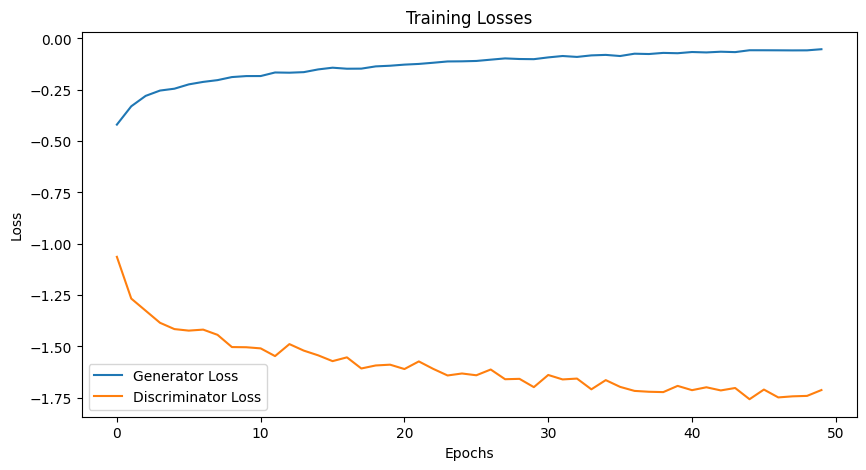

Discriminator Architecture:
0: Flatten(start_dim=1, end_dim=-1)
1: Linear(in_features=4096, out_features=512, bias=True)
2: BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
3: ReLU()
4: Linear(in_features=512, out_features=256, bias=True)
5: BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
6: ReLU()
7: Linear(in_features=256, out_features=1, bias=True)
8: Sigmoid()
Quantum Circuit Diagram:
     ┌──────────────┐┌───────────────┐┌───────────────┐
q_0: ┤ Rx(input[0]) ├┤ Ry(weight[0]) ├┤ Ry(weight[4]) ├
     ├──────────────┤├───────────────┤├───────────────┤
q_1: ┤ Rx(input[1]) ├┤ Ry(weight[1]) ├┤ Ry(weight[5]) ├
     ├──────────────┤├───────────────┤├───────────────┤
q_2: ┤ Rx(input[2]) ├┤ Ry(weight[2]) ├┤ Ry(weight[6]) ├
     ├──────────────┤├───────────────┤├───────────────┤
q_3: ┤ Rx(input[3]) ├┤ Ry(weight[3]) ├┤ Ry(weight[7]) ├
     └──────────────┘└───────────────┘└───────────────┘
Generator Learning Rate: 0.00015
Discri

In [22]:
# 1) Import Modules
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
from qiskit.circuit import ParameterVector
from qiskit.primitives import Sampler
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.connectors import TorchConnector
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# 2) Load MVTec-AD Data
class MVTecADLoader(Dataset):
    def __init__(self, root_dir):
        self.image_files = [os.path.join(root_dir, f) for f in os.listdir(root_dir) 
                            if f.lower().endswith(('.png', 'jpg', 'jpeg'))]
        self.transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        return self.transform(Image.open(self.image_files[idx]).convert('L')), 0

# Configuration
class Config:
    category = "bottle"
    base_path = "/kaggle/input/mvtec-ad"
    img_size = 64
    latent_dim = 4
    num_qubits = 4
    depth = 2
    batch_size = 16
    epochs = 50
    learning_rate_g = 0.00015
    learning_rate_d = 0.000075

config = Config()

# 4) Classical Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*64*1, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# 5) Print Discriminator Diagram
def print_discriminator_diagram(disc):
    print("Discriminator Architecture:")
    for name, module in disc.model.named_children():
        print(f"{name}: {module}")

# 6) Quantum Generator
def create_quantum_circuit():
    input_params = ParameterVector('input', config.latent_dim)
    weights = ParameterVector('weight', config.num_qubits * config.depth)

    qc = QuantumCircuit(config.num_qubits)

    # Input encoding
    for i in range(config.latent_dim):
        qc.rx(input_params[i], i)
    
    # Parametrized layers
    weight_idx = 0
    for _ in range(config.depth):
        for qubit in range(config.num_qubits):
            qc.ry(weights[weight_idx], qubit)
            weight_idx += 1

    return qc

class QuantumGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.qc = create_quantum_circuit()
        params = self.qc.parameters
        
        self.qnn = SamplerQNN(
            circuit=self.qc,
            input_params=params[:config.latent_dim],
            weight_params=params[config.latent_dim:],
            sampler=Sampler(),
            output_shape=2**config.num_qubits,
            input_gradients=True
        )
        
        self.hybrid_layer = TorchConnector(
            self.qnn,
            initial_weights=torch.randn(len(params)-config.latent_dim)*0.01
        )
        
        self.post_process = nn.Linear(16, config.img_size**2)

    def forward(self, z):
        z = z.view(-1, config.latent_dim)
        return self.post_process(self.hybrid_layer(z)).view(-1, 1, 64, 64)

# 7) Print Quantum Circuit Diagram
def print_quantum_circuit_diagram(gen):
    print("Quantum Circuit Diagram:")
    # Use circuit_drawer instead of plot_circuit
    circuit_str = circuit_drawer(gen.qc, output='text')
    print(circuit_str)

# 8) Training Function
def train_qgan():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    gen = QuantumGenerator().to(device)
    disc = Discriminator().to(device)

    opt_g = torch.optim.RMSprop(gen.parameters(), lr=config.learning_rate_g)
    opt_d = torch.optim.RMSprop(disc.parameters(), lr=config.learning_rate_d)

    train_path = f"{config.base_path}/{config.category}/train/good"
    train_set = MVTecADLoader(train_path)
    train_loader = torch.utils.data.DataLoader(
        train_set,
        batch_size=config.batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=2
    )

    g_losses = []
    d_losses = []

    print("Training started...")
    for epoch in range(config.epochs):
        epoch_g_loss = 0
        epoch_d_loss = 0

        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            
            # Train Discriminator
            z = torch.randn(config.batch_size*4).view(-1,4).to(device)
            
            with torch.no_grad():
                fake_imgs = gen(z)
            
            real_loss = -torch.mean(disc(real_imgs))
            fake_loss = -torch.mean(1 - disc(fake_imgs))
            
            d_loss = real_loss + fake_loss
            
            disc.zero_grad()
            d_loss.backward()
            opt_d.step()
            
            # Train Generator (Hybrid Backprop)
            z = torch.randn(config.batch_size*4).view(-1,4).to(device)
            
            fake_imgs = gen(z)
            
            g_loss = -torch.mean(disc(fake_imgs))
            
            gen.zero_grad()
            g_loss.backward()
            opt_g.step()

            # Store losses
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()

        # Average losses per epoch
        g_losses.append(epoch_g_loss / len(train_loader))
        d_losses.append(epoch_d_loss / len(train_loader))
        
        print(f"Epoch {epoch+1}/{config.epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    # 9) Save Model
    torch.save(gen.state_dict(), 'quantum_generator.pth')
    torch.save(disc.state_dict(), 'classical_discriminator.pth')

    # Plot learning curves
    plot_learning_curves(g_losses, d_losses)

    return gen, disc, g_losses, d_losses

# 10) Learning Rate and Formulas
def print_learning_rates():
    print(f"Generator Learning Rate: {config.learning_rate_g}")
    print(f"Discriminator Learning Rate: {config.learning_rate_d}")
    print("Loss Formula: Wasserstein Loss with Gradient Penalty")

# 11) Anomaly Detection
def anomaly_score(generator, input_img):
    with torch.no_grad():
        reconstructed_img = generator(input_img.view(-1, 4))
        return torch.mean((input_img - reconstructed_img)**2).item()

# 12) Visualization
def visualize_results(original, reconstructed, anomaly_score):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original.squeeze(), cmap='gray')
    axes[0].set_title('Original Image')
    axes[1].imshow(reconstructed.squeeze(), cmap='gray')
    axes[1].set_title('Reconstructed Image')
    axes[2].imshow(np.abs(original.squeeze() - reconstructed.squeeze()), cmap='viridis')
    axes[2].set_title(f'Anomaly Map (Score: {anomaly_score:.4f})')
    plt.show()

# 13) Learning Curves
def plot_learning_curves(g_losses, d_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(g_losses, label='Generator Loss')
    plt.plot(d_losses, label='Discriminator Loss')
    plt.title('Training Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# 14) Performance Metrics
def calculate_metrics(true_labels, predicted_labels):
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predicted_labels, average='binary')
    print("Performance Metrics:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

# 15) Confusion Matrix
def plot_confusion_matrix(true_labels, predicted_labels):
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Main Execution
if __name__ == "__main__":
    # Train the model
    generator, discriminator, g_losses, d_losses = train_qgan()
    
    # Print model details
    print_discriminator_diagram(discriminator)
    print_quantum_circuit_diagram(generator)
    print_learning_rates()
